In [88]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import datetime as dt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import shap
from xgboost import XGBClassifier


In [89]:
df=pd.read_csv("../data/online_retail_II.csv")

In [90]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  


In [91]:
df=df.drop_duplicates()
print("After dropping duplicates:", df.shape)
print(df.columns.tolist())


After dropping duplicates: (1033036, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [92]:
df=df.dropna(subset=['Customer ID'])
print("After dropping missing Customer ID:", df.shape)
df=df.dropna(subset=['Description'])
print("After dropping missing Description:",df.shape)

After dropping missing Customer ID: (797885, 8)
After dropping missing Description: (797885, 8)


In [93]:
print(df['Invoice'].head(20))

0     489434
1     489434
2     489434
3     489434
4     489434
5     489434
6     489434
7     489434
8     489435
9     489435
10    489435
11    489435
12    489436
13    489436
14    489436
15    489436
16    489436
17    489436
18    489436
19    489436
Name: Invoice, dtype: object


In [94]:
print(df['Invoice'].astype(str).str.startswith('C').sum())
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(cancelled.shape)
print(cancelled.head(20))



18390
(18390, 8)
     Invoice StockCode                          Description  Quantity  \
178  C489449     22087             PAPER BUNTING WHITE LACE       -12   
179  C489449    85206A         CREAM FELT EASTER EGG BASKET        -6   
180  C489449     21895        POTTING SHED SOW 'N' GROW SET        -4   
181  C489449     21896                   POTTING SHED TWINE        -6   
182  C489449     22083           PAPER CHAIN KIT RETRO SPOT       -12   
183  C489449     21871                  SAVE THE PLANET MUG       -12   
184  C489449     84946      ANTIQUE SILVER TEA GLASS ETCHED       -12   
185  C489449    84970S    HANGING HEART ZINC T-LIGHT HOLDER       -24   
186  C489449     22090            PAPER BUNTING RETRO SPOTS       -12   
196  C489459    90200A           PURPLE SWEETHEART BRACELET        -3   
197  C489459    90200D             PINK SWEETHEART BRACELET        -3   
198  C489459    90200B            BLACK SWEETHEART BRACELET        -3   
199  C489459    90200E            

In [95]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', None)

In [96]:
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [97]:
pd.set_option('display.max_columns', None)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [98]:
df=df[~df['Invoice'].astype(str).str.startswith('C')]

In [99]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df = df.dropna(subset=['Customer ID'])

In [100]:
print("Final shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

Final shape: (779425, 8)
Missing values:
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [101]:
df['InvoiceDate'] =pd.to_datetime(df['InvoiceDate'])
reference_date=df['InvoiceDate'].max()+ dt.timedelta(days=1)

In [102]:
df['TotalPrice']=df['Quantity']*df['Price']

In [103]:
rfm=df.groupby('Customer ID').agg(Recency=('InvoiceDate',lambda x:(reference_date -x.max()).days),Frequency=('Invoice','nunique'),Monetary=('TotalPrice' , 'sum')).reset_index()

In [104]:
print(rfm.head())
print(rfm.shape)
print(rfm.describe())


   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   4921.53
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40
(5878, 4)
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    2955.904095
std     1715.572666   209.338707    13.009406   14440.852688
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     342.280000
50%    15314.500000    96.000000     3.000000     867.740000
75%    16797.750000   380.000000     7.000000    2248.305000
max    18287.000000   739.000000   398.000000  580987.040000


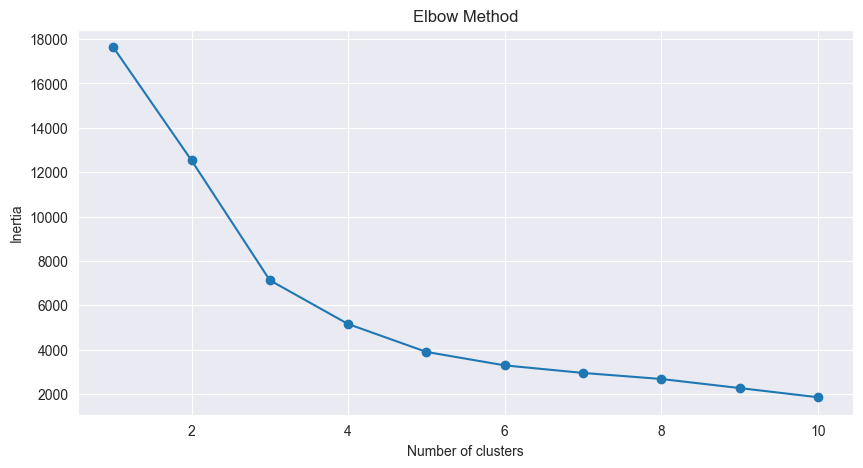

In [105]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

inertia=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    
plt.figure(figsize=(10,5))
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [106]:
km=KMeans(n_clusters=3,random_state=42)
rfm['Cluster']=km.fit_predict(rfm_scaled)
print(rfm.head(10))
print(rfm['Cluster'].value_counts())

   Customer ID  Recency  Frequency  Monetary  Cluster
0      12346.0      326         12  77556.46        1
1      12347.0        2          8   4921.53        1
2      12348.0       75          5   2019.40        1
3      12349.0       19          4   4428.69        1
4      12350.0      310          1    334.40        0
5      12351.0      375          1    300.93        0
6      12352.0       36         10   2849.84        1
7      12353.0      204          2    406.76        1
8      12354.0      232          1   1079.40        1
9      12355.0      214          2    947.61        1
Cluster
1    3846
0    2010
2      22
Name: count, dtype: int64


In [107]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,461.784577,2.212438,748.384713
1,66.233489,7.637806,3136.201806
2,23.090909,143.045455,173123.584091


In [108]:
cluster_labels={
    0:'Lost Customers',
    1:'Medium Value',
    2:'High Value',
}

rfm['Segment']=rfm['Cluster'].map(cluster_labels)
print(rfm.head(20))
print(rfm['Segment'].value_counts())

    Customer ID  Recency  Frequency  Monetary  Cluster         Segment
0       12346.0      326         12  77556.46        1    Medium Value
1       12347.0        2          8   4921.53        1    Medium Value
2       12348.0       75          5   2019.40        1    Medium Value
3       12349.0       19          4   4428.69        1    Medium Value
4       12350.0      310          1    334.40        0  Lost Customers
5       12351.0      375          1    300.93        0  Lost Customers
6       12352.0       36         10   2849.84        1    Medium Value
7       12353.0      204          2    406.76        1    Medium Value
8       12354.0      232          1   1079.40        1    Medium Value
9       12355.0      214          2    947.61        1    Medium Value
10      12356.0       23          6   6371.73        1    Medium Value
11      12357.0       33          3  18287.66        1    Medium Value
12      12358.0        2          5   3887.07        1    Medium Value
13    

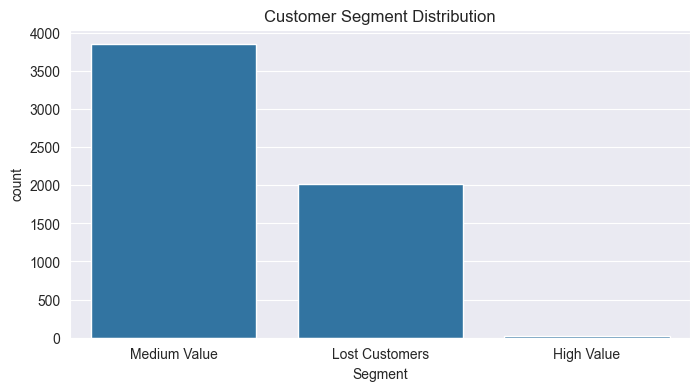

In [109]:
plt.figure(figsize=(8,4))
sns.countplot(data=rfm,x='Segment')
plt.title('Customer Segment Distribution')
plt.show()

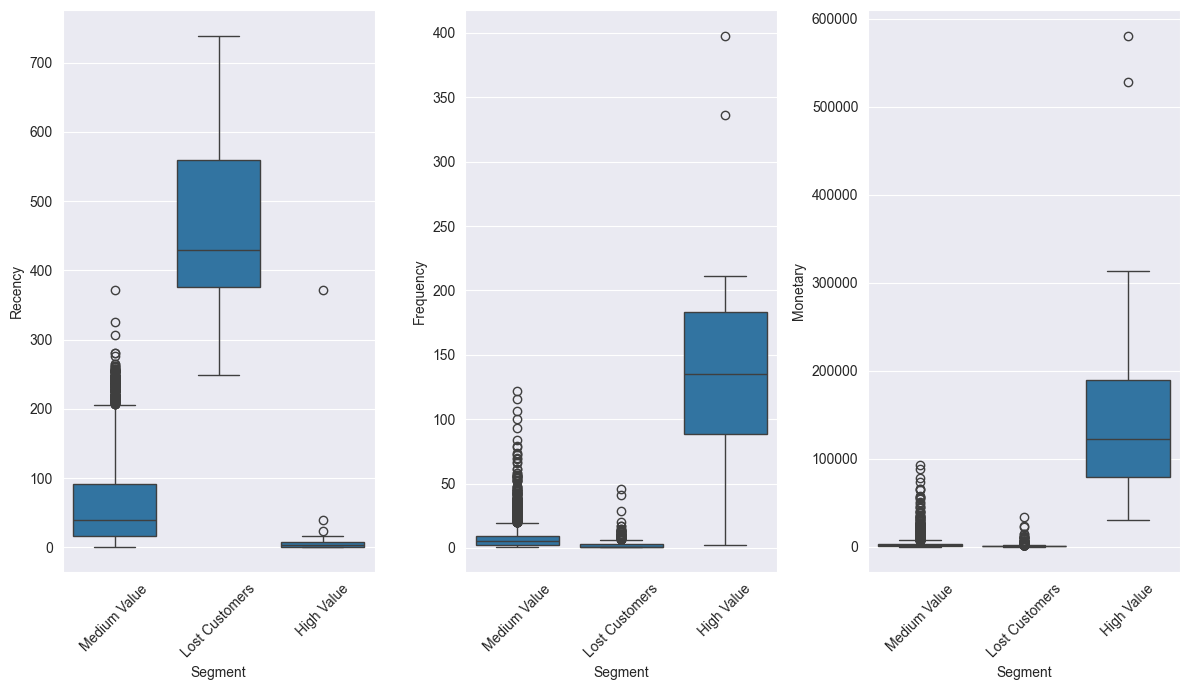

In [110]:
plt.figure(figsize=(12,7))
for i,col in enumerate(['Recency','Frequency','Monetary']):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=rfm,x='Segment',y=col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [111]:
X = scaler.fit_transform(
    rfm[['Recency','Frequency','Monetary']]
)
y = rfm['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

weights = {
    0: 1,
    1: 1,
    2: 50,
}

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Test all segments
print("\nChampion test:", model.predict([[4, 213, 428612]])[0])
print("High Value test:", model.predict([[26, 104, 81356]])[0])
print("Medium test:", model.predict([[67, 7, 2949]])[0])
print("Lost test:", model.predict([[462, 2, 749]])[0])
print(rfm['Cluster'].value_counts())
print(model.predict(scaler.transform([[462,2,749]])))
print(model.predict(scaler.transform([[67,7,2949]])))
print(model.predict(scaler.transform([[26,104,81356]])))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       402
           1       1.00      1.00      1.00       770
           2       0.80      1.00      0.89         4

    accuracy                           1.00      1176
   macro avg       0.93      1.00      0.96      1176
weighted avg       1.00      1.00      1.00      1176


Champion test: 2
High Value test: 2
Medium test: 2
Lost test: 0
Cluster
1    3846
0    2010
2      22
Name: count, dtype: int64
[0]
[1]
[2]


D:\Customer_Lifetime_Value\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\Customer_Lifetime_Value\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\Customer_Lifetime_Value\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(1176, 3, 3)
<class 'numpy.ndarray'>
(1176, 3, 3)

Segment: Lost Customers


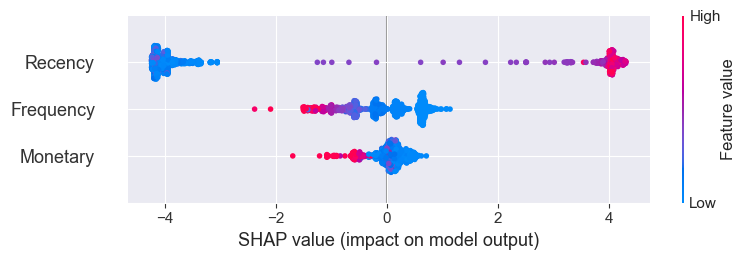


Segment: Medium Value


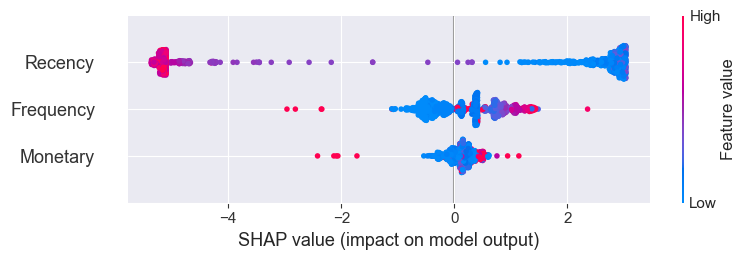


Segment: High Value


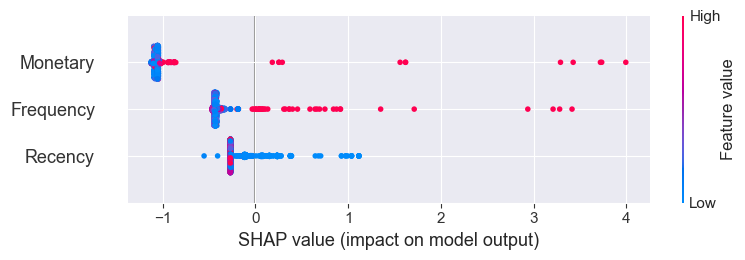

In [112]:

import numpy as np

X_test = np.array(X_test, dtype=np.float32)

explainer = shap.TreeExplainer(model)

shap_exp = explainer(X_test)

shap_values = shap_exp.values

print(shap_values.shape)

segment_names = [
    'Lost Customers',
    'Medium Value',
    'High Value'
]

print(type(shap_values))
print(shap_values.shape)

for i in range(3):

    print(f"\nSegment: {segment_names[i]}")

    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        feature_names=['Recency', 'Frequency', 'Monetary'],
        show=True)
    
  

In [113]:
joblib.dump(model, '../models/clv_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(explainer, '../models/shap_explainer.pkl')

['../models/shap_explainer.pkl']